# 3.3 Non-smooth physics

Parameterizations are full of switches. Convection triggers when instability crosses a
threshold; water freezes at 0 °C; fluxes are clipped to keep quantities positive. Each
switch is an `if` in physical clothing — and at a switch, the derivative is zero on
both sides and undefined at the jump. Automatic differentiation handles such code
without complaint and returns something *technically correct and scientifically
useless*: the slope of the flat parts.

This chapter builds the failure in its purest form — a precipitation trigger — and
repairs it three ways, in increasing order of sophistication: smooth the physics,
reformulate the physics, or keep the physics and prescribe a better derivative.

```{admonition} Learning goals
:class: tip
- Predict what autodiff returns at `where`/`maximum`-style thresholds
- Recognize the signature of a switch-dominated loss: it varies, yet its gradient is zero
- Repair by smoothing, and measure both of smoothing's failure modes
- Repair with `jax.custom_vjp` — exact forward physics, informative backward pass
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

## The microscale of the problem

Three one-liners set the scene. A hard threshold has zero derivative almost
everywhere; a kink (`maximum`) has a subgradient JAX resolves by convention; and the
innocent-looking `where` can poison a gradient with NaN when its *untaken* branch is
non-differentiable at the evaluation point — the backward pass evaluates both branches:

In [2]:
step_fn = lambda x: jnp.where(x > 0.0, 1.0, 0.0)
kink_fn = lambda x: jnp.maximum(x, 0.0)
print("d/dx step at -1, +1:   ", jax.grad(step_fn)(-1.0), jax.grad(step_fn)(1.0))
print("d/dx max(x,0) at 0:    ", jax.grad(kink_fn)(0.0), "  (JAX picks a one-sided value)")

bad = lambda x: jnp.where(x > 0.0, jnp.sqrt(x), 0.0)
good = lambda x: jnp.where(x > 0.0, jnp.sqrt(jnp.where(x > 0.0, x, 1.0)), 0.0)
print("naive where + sqrt, grad at 0:", jax.grad(bad)(0.0))
print("double-where fix,  grad at 0: ", jax.grad(good)(0.0))

d/dx step at -1, +1:    0.0 0.0
d/dx max(x,0) at 0:     0.5   (JAX picks a one-sided value)
naive where + sqrt, grad at 0: nan
double-where fix,  grad at 0:  0.0


The `nan` arises because $d\sqrt{x}/dx \to \infty$ at 0 is multiplied by the
`where` mask's 0, and $0 \times \infty$ is NaN; the *double-where* idiom feeds the
dangerous branch a harmless value first. File it away — it is the most common source
of mystery NaNs in differentiable models (Chapter 3.5 shows how to hunt them).

## A convective-trigger toy

Now the failure at model scale. A single atmospheric column accumulates moisture from
a prescribed, weather-like supply; when column water $w$ exceeds a critical value
$w_c$, precipitation removes it at a fixed rate $P_0$ — an on/off trigger of the kind
convection schemes have used for decades. The scientific task: given observations of
the column's mean water content, calibrate $w_c$.

observed mean column water: 24.43 kg m^-2;  raining 26% of the time


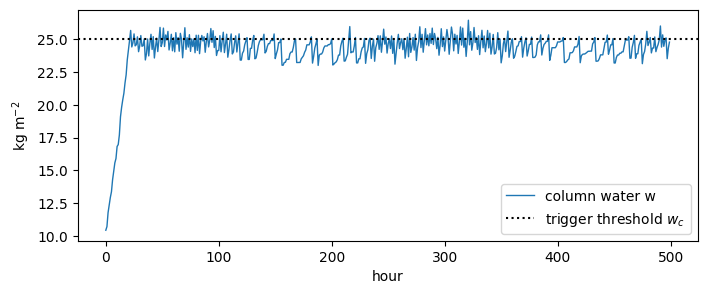

In [3]:
DT_H = 1.0                       # time step, hours
N_STEPS = 2000
P0 = 2.0                         # precipitation rate when triggered, kg m^-2 per hour
key = jax.random.key(0)
supply = jnp.clip(0.5 * (1.0 + 0.8 * jnp.sin(2 * jnp.pi * jnp.arange(N_STEPS) / 240.0))
                  + 0.3 * jax.random.normal(key, (N_STEPS,)), 0.0, None)

def simulate(w_crit, precip):
    def one(w, E):
        P = precip(w, w_crit)
        w = jnp.clip(w + DT_H * (E - P), 0.0, None)
        return w, (w, P)
    _, (w, P) = jax.lax.scan(one, 10.0, supply)
    return w, P

hard_trigger = lambda w, w_crit: jnp.where(w > w_crit, P0, 0.0)

W_TRUE = 25.0
w_truth, P_truth = simulate(W_TRUE, hard_trigger)
OBS = float(jnp.mean(w_truth))
print(f"observed mean column water: {OBS:.2f} kg m^-2;  raining {float(jnp.mean(P_truth > 0)):.0%} of the time")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(w_truth[:500], lw=1, label="column water w")
ax.axhline(W_TRUE, color="k", ls=":", label="trigger threshold $w_c$")
ax.set_xlabel("hour"); ax.set_ylabel("kg m$^{-2}$"); ax.legend()
plt.show()

## The failure: a loss that varies, and a gradient that is zero

The calibration loss clearly depends on $w_c$ — and its derivative is identically
zero. The trigger's timing changes in discrete jumps as $w_c$ varies, so the loss is a
staircase: thousands of microscopic treads, each perfectly flat. Plotted at normal
resolution it even *looks* smooth, which makes this failure mode treacherous — nothing
warns you except the gradient's suspicious exactness:

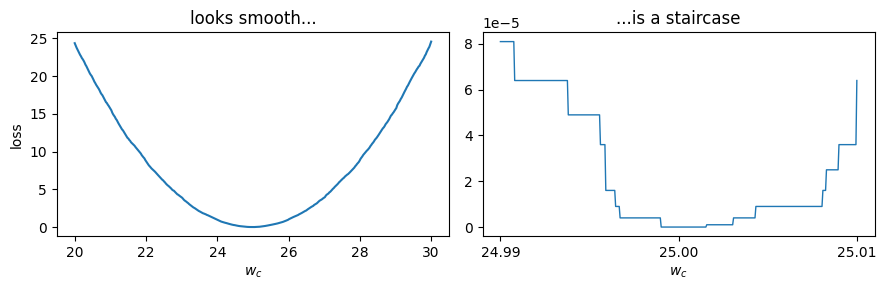

gradients: [0.0, 0.0, 0.0, 0.0]


In [4]:
def loss_hard(w_crit):
    w, _ = simulate(w_crit, hard_trigger)
    return (jnp.mean(w) - OBS) ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
wc_wide = jnp.linspace(20.0, 30.0, 400)
ax1.plot(wc_wide, jax.vmap(loss_hard)(wc_wide))
ax1.set_xlabel("$w_c$"); ax1.set_ylabel("loss"); ax1.set_title("looks smooth...")
wc_zoom = jnp.linspace(24.99, 25.01, 400)
ax2.plot(wc_zoom, jax.vmap(loss_hard)(wc_zoom), lw=1)
ax2.set_xticks([24.99, 25.0, 25.01])
ax2.set_xlabel("$w_c$"); ax2.set_title("...is a staircase")
plt.tight_layout(); plt.show()

print("gradients:", [float(jax.grad(loss_hard)(wc)) for wc in [20.0, 23.0, 25.0, 27.0]])

Gradient descent receives zero at every point and goes nowhere. Note the contrast
with Chapter 3.1: there the gradient was huge and meaningless; here it is zero and
meaningless. Exact differentiation of the wrong microstructure produces both.

## Fix 1: smooth the switch

Replace the on/off trigger with a sigmoid of width $\delta$: precipitation ramps up
smoothly around $w_c$. The gradient immediately becomes informative — at the price of
changed physics, and the price depends on $\delta$ in both directions:

In [5]:
import optax

def calibrate(precip, w0=20.0, n=300, lr=0.2):
    wc, opt = jnp.array(w0), optax.adam(lr)
    state = opt.init(wc)
    def loss(w_crit):
        w, _ = simulate(w_crit, precip)
        return (jnp.mean(w) - OBS) ** 2
    step = jax.jit(jax.value_and_grad(loss))
    for _ in range(n):
        L, g = step(wc)
        updates, state = opt.update(g, state)
        wc = optax.apply_updates(wc, updates)
    return float(wc)

print("smoothing width   recovered w_c (truth 25.0)   drizzle below threshold")
for delta in [2.0, 0.5, 0.1]:
    smooth = lambda w, w_crit, d=delta: P0 * jax.nn.sigmoid((w - w_crit) / d)
    wc = calibrate(smooth)
    w, P = simulate(wc, lambda w_, c_: P0 * jax.nn.sigmoid((w_ - c_) / delta))
    drizzle = float(jnp.sum(jnp.where(w < wc, P, 0.0)) / jnp.sum(P))
    print(f"   {delta:4.1f}              {wc:6.2f}                     {drizzle:.0%} of total rain")

smoothing width   recovered w_c (truth 25.0)   drizzle below threshold


    2.0               26.89                     94% of total rain
    0.5               25.14                     83% of total rain


    0.1               28.79                     91% of total rain


The sweet spot is real but narrow. Too wide ($\delta = 2$): the model drizzles
far from the threshold, its climate is biased, and the recovered $w_c$ inherits the
bias. Too narrow ($\delta = 0.1$): the sigmoid approaches the original staircase, the
gradient signal collapses into spikes, and the optimizer strands far from truth. And
at *any* width, the forward physics is altered — here a large share of rain falls in
conditions where the true model produces none. Smoothing is a legitimate modeling
decision (many modern schemes prefer smooth triggers on physical grounds); it is a
poor afterthought.

## Fix 2: reformulate the physics

Sometimes the discreteness is an implementation habit rather than a physical claim. A
ramp trigger — precipitation proportional to the water excess,
$P = k\,\max(w - w_c,\, 0)$ — is as defensible physically, and its kink passes an
informative (one-sided) gradient. Where a reformulation exists, it is the cleanest
answer: the model you differentiate is the model you mean. The exercise below asks you
to run it; the pattern to notice is that *choosing differentiable physics up front*
beats repairing non-differentiable physics after the fact.

## Fix 3: keep the physics, prescribe the derivative

When the hard switch *is* the model you mean, JAX allows a division of labor: the
forward pass runs the exact discontinuous physics, and `jax.custom_vjp` substitutes a
chosen derivative — here, the sigmoid's — in the backward pass:

In [6]:
@jax.custom_vjp
def trigger(w, w_crit):
    return jnp.where(w > w_crit, P0, 0.0)          # exact forward physics

def trigger_fwd(w, w_crit):
    return trigger(w, w_crit), (w, w_crit)

def trigger_bwd(saved, dLdP):
    w, w_crit = saved
    s = jax.nn.sigmoid((w - w_crit) / 0.5)          # surrogate slope, width 0.5
    dP = P0 * s * (1 - s) / 0.5
    return (dLdP * dP, -dLdP * dP)

trigger.defvjp(trigger_fwd, trigger_bwd)

wc = calibrate(trigger)
print(f"custom_vjp calibration: recovered w_c = {wc:.3f}   (truth 25.0)")
w, P = simulate(wc, trigger)
print(f"forward physics exact: rain rate is only ever 0 or {P0}: "
      f"{bool(jnp.all((P == 0) | (P == P0)))}")

custom_vjp calibration: recovered w_c = 25.001   (truth 25.0)


forward physics exact: rain rate is only ever 0 or 2.0: True


Recovered to three decimal places, with the simulated physics bit-for-bit the hard
trigger. The backward pass is now a lie — a deliberate, controlled one: the surrogate
derivative says "moving $w_c$ down makes rain more likely near the threshold," which
is true *on average* even though the pointwise derivative is zero. Machine learning
knows this trick as the **straight-through estimator**, standard equipment for
training through quantization and sampling {cite}`blondel2024elements`; the physical
sciences increasingly use it for thresholds exactly like this one. Its limits: the
surrogate's bias is uncontrolled (no convergence theorem stands behind it), so the
result deserves the verification habits of Chapter 3.5 — does the calibrated model
match observations it was not trained on?

Three fixes, one decision rule: **smooth** if a smooth model is physically acceptable
(and report the width as a model parameter); **reformulate** if the discreteness was
never physical; **surrogate-gradient** if the discontinuous physics must stand. What
is not on the menu is differentiating the hard switch and hoping — the zeros
propagate silently into any larger model containing them.

**Exercises.**
1. Implement the ramp trigger $P = 0.4\,\max(w - w_c, 0)$, generate its own truth,
   and calibrate. Why does even the *one-sided* kink gradient suffice here?
2. Vary the surrogate width in `trigger_bwd` over {0.1, 0.5, 2.0}. Which parts of the
   smoothing trade-off return, and which do not?
3. The ice line of Part 2 used tanh with a 2 K width — a Fix-1 choice made for you.
   Re-run Chapter 2.2's calibration with width 0.2 K. What happens to the loss
   landscape and the descent?